In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from statsmodels.tsa.holtwinters import SimpleExpSmoothing

In [2]:
np.random.seed(5)
data = np.random.normal(0,1,100) + np.linspace(0,1,100)
data[50] = 4

In [4]:
modelo = SimpleExpSmoothing(data)
modelo_fit = modelo.fit(smoothing_level=0.2, optimized=False)

In [5]:
data_pred = modelo_fit.predict(0,len(data) - 1)

In [7]:
anomalies = np.where(np.abs(data - data_pred) > 3 * np.std(data))[0]
anomalies

array([50])

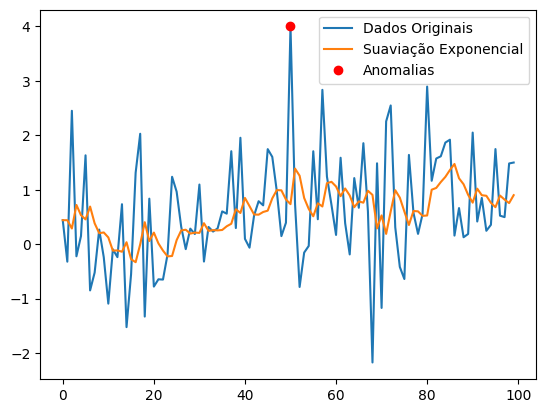

In [8]:
plt.plot(data, label='Dados Originais')
plt.plot(data_pred, label='Suaviação Exponencial')
plt.plot(anomalies, data[anomalies], 'ro', label='Anomalias')
plt.legend()
plt.show()